In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

## Likelihood and Estimation

A normal model was chosen for this part because the paddy yield is the target variable and it is a continuous variable.

In [ ]:
# Likelihood:
# L(mu, sigma^2) = product over i of [1 / sqrt(2*pi*sigma^2)] * exp(-(y_i - mu)^2 / (2*sigma^2))

# Log-likelihood:
# l(mu, sigma^2) = -(n/2)log(2*pi) - (n/2)log(sigma^2) - (1/(2*sigma^2)) * sum((y_i - mu)^2)

In [ ]:
df = pd.read_csv("paddydataset.csv")

y = df["Paddy yield(in Kg)"].dropna().to_numpy()
n = len(y)

#MLE estimates for normal model
mu_hat = np.mean(y)
sigma2_hat = np.mean((y - mu_hat) ** 2)
sigma_hat = np.sqrt(sigma2_hat)

print(f"Mean of Paddy Yield: {mu_hat:.2f}")
print(f"Variance of Paddy Yield: {sigma2_hat:.2f}")
print(f"Standard Deviation of Paddy Yield: {sigma_hat:.2f}")

Mean of Paddy Yield: 22517.73
Variance of Paddy Yield: 84603424.18
Standard Deviation of Paddy Yield: 9198.01


In [ ]:
def log_likelihood_mu(mu, y, sigma2):
    n = len(y)
    return -(n/2) * np.log(2 * np.pi * sigma2) - (1/(2 * sigma2)) * np.sum((y - mu)**2)

mu_grid = np.linspace(y.min(), y.max(), 400)
ll_values = [log_likelihood_mu(mu, y, sigma2_hat) for mu in mu_grid]

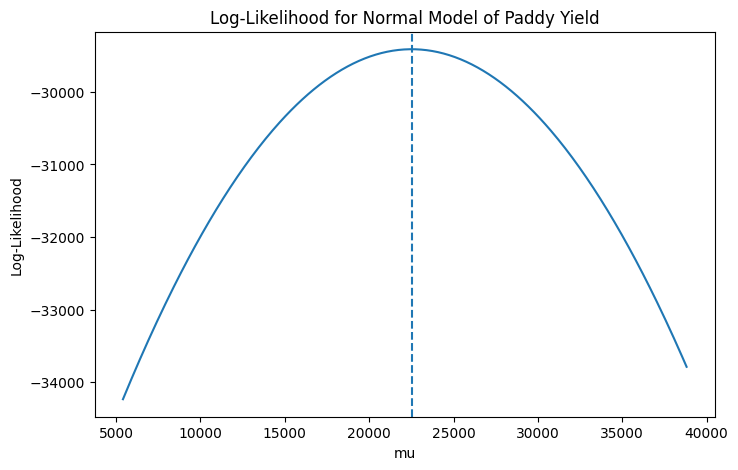

In [ ]:
#plot log likeliehood
plt.figure(figsize=(8,5))
plt.plot(mu_grid, ll_values)
plt.axvline(mu_hat, linestyle="--")
plt.xlabel("mu")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood for Normal Model of Paddy Yield")
plt.show()